<a href="https://colab.research.google.com/github/DDORINY/study_AI_26/blob/main/00.%20%EB%B6%80%ED%8A%B8%EC%BA%A0%ED%94%84_%ED%95%99%EC%8A%B5/07_03_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D%EA%B8%B0%ED%83%80%EB%8F%84%EA%B5%AC(%EB%93%9C%EB%A1%AD%EC%95%84%EC%9B%83%2C%EC%BD%9C%EB%B0%B1%2C%EC%A1%B0%EA%B8%B0%EC%A2%85%EB%A3%8C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **인공신경망을 구성하는 절차**


1.   더미데이터 준비
2.   훈련용, 검증용, 테스트용으로 나눔
3.   심층을 만듬(dense)
4.   model에 적용 (Sequential)
5.   컴파일 진행(최적의기법을 적용 : adam)
6.   fit(훈련)
7.   evaluate(검증)
8.   predict(예측)<br>

---

**손실 곡선** : fit() 메서드로 모델을 훈련하는 동안 훈련과정이 상세하게 출력되어 확인 할 수 있다. (에포크 횟수, 손실, 정확도) <br>
아래 쪽에 이 출력 메세지가 나옴<br>
코렙 노트북에 코드셀은 print() 명령어를 사용하지 않아도 마지막 라인에 실행결과를 자동으로 출력<br>
<br>
다시 말해 fit() 메서드는 History라는 클래스 객체를 반환 함 (훈련과정의 지표, 손실, 정확도 등 내장)<br>
이 값을 잘 활용하면 그래프를 그릴 수 았다.


---

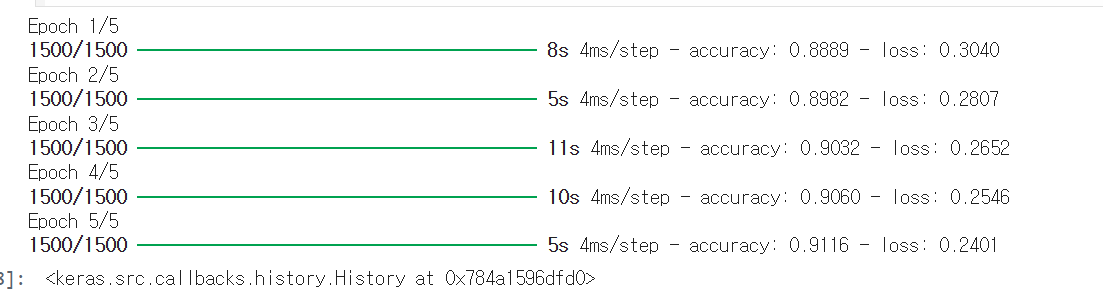


In [32]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()
# 엔터효과 제거용 \ -> 한줄로 긴 문장을 자름.

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [33]:
print("훈련용데이터 :")
print(train_scaled.shape, train_target.shape)
print("테스트데이터:")
print(test_input.shape,test_target.shape)
print("검증데이터:")
print(val_scaled.shape, val_target.shape)

훈련용데이터 :
(48000, 28, 28) (48000,)
테스트데이터:
(10000, 28, 28) (10000,)
검증데이터:
(12000, 28, 28) (12000,)


#### **모델을 만드는 함수를 정의 함**
하나의 매개변수를 받아 리턴<br>
.model_fn(dense추가하면 생성)

In [34]:
def model_fn(a_layer = None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28,28)))        # 반복적으로 사용되는 입력 층
    model.add(keras.layers.Dense(100, activation='relu'))       # 반복적으로 사용되는 2진 분류 층

    # model_fn() 함수에 (a_layer 매개변수로) 케라스 층을 추가하면 은닉층 뒤에 하나의 층을 추가함.
    if a_layer:
        model.add(a_layer)                                      # 매개값으로 넘어오는 추가되는 층
    model.add(keras.layers.Dense(10, activation = 'softmax'))   # 반복적으로 사용되는 다중분류층
    return model

In [35]:
model = model_fn()  # 위에서 만든 매서드 호출하여 모델에 담음
#       model_fn(매개값이 없으면 그냥 생성, 매개값이 있으면 모델 추가용)
model.summary()     # 모델의 요약정보를 봄

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#                     다중분류                                      정확도

#### **fit() 메서드 결과를 history 변수에 담아보자

In [37]:
history = model.fit(train_scaled, train_target, epochs = 5, verbose = 2 )

Epoch 1/5
1500/1500 - 5s - 4ms/step - accuracy: 0.8112 - loss: 0.5311
Epoch 2/5
1500/1500 - 6s - 4ms/step - accuracy: 0.8586 - loss: 0.3903
Epoch 3/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8729 - loss: 0.3523
Epoch 4/5
1500/1500 - 4s - 2ms/step - accuracy: 0.8810 - loss: 0.3306
Epoch 5/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8873 - loss: 0.3141


**훈련과정을 출력을 조절한다**<br>
`verbose=0` 훈련과정을 나타내지 않음 <br>
`verbose=1` 기본값, 에포크마다 진행 막대와 함께 손실등의 지표가 출력 <br>
`verbose=2` 진행막대 빼고 출력

In [38]:
print(history)

위에 fit한 결과를 History객체가 가지고 있는데 이것을 history 변수에 담음

In [39]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


훈련 측정 값이 담겨 있는 history 딕셔너리가 존재함 <br>
정확도 **accuracy**, 손실 **loss** 값이 있다. <br>
<br>
정확도는 **complie()**메서드의 **metrics**매개변수에 **accuracy**를 추가 했기 떄문에 <br>
**histroy** 속성에 포함되었음

### **matplotlib를 이용해 차트로 보기**
손실율을 차트로 표시해보자

In [40]:
import matplotlib.pyplot as plt

history속성에 포함된 손실과 정확도는 에포크마다 계산한 값이<br>
순서대로 나열된 단순한 리스트로 맷플롯립으로 쉽게 그래프 처리가 가능

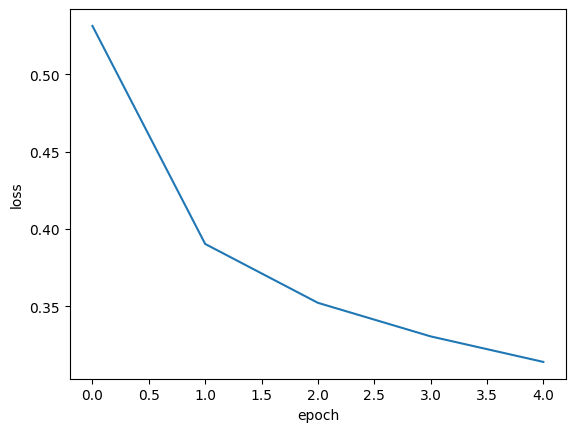

In [41]:
plt.plot(history.history['loss']) # 손실율을 차트로 표시
plt.xlabel('epoch')
# 파이썬 인덱스는 0부터 시작함 5개의 에포크가 0 ~ 4까지 x축에 표현
plt.ylabel('loss') #손실된 값
plt.show()

이번에는 정확도를 출력

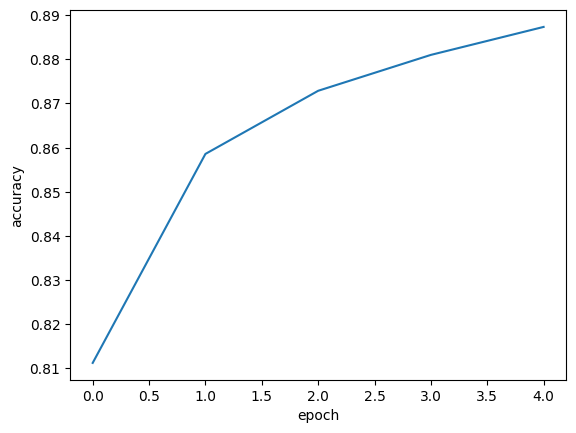

In [42]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

**결과분석** : 에포크마다 손실이 감소하고 정확도가 향상함

이번에는 에포크 횟수를 20번으로 늘려보자!

In [43]:
model = model_fn()

위에서 만든 메서드로 모델 생성(3개층 입력층, 은닉층, 출력층)

In [44]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs = 20, verbose = 0)

손실율과 정확도를 한 번에 차트로 보자!

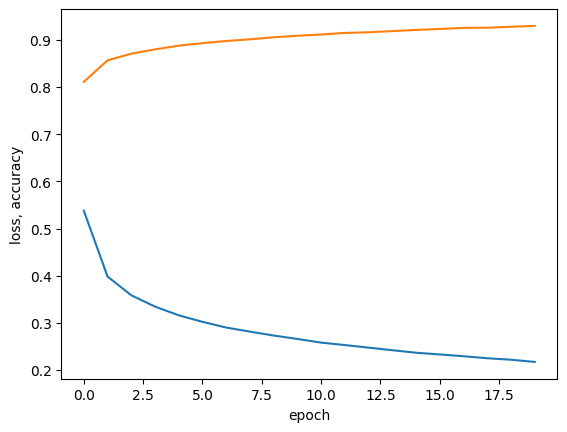

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.show()

**검증 손실**<br>
`validation_data=(val_scaled, val_target)`<br>
예전에 확률적 경사 하강법을 사용 했을 때 과대/과소 적합과 에포크 사이에 관계 부분이 있었다. <br>
인공 신경망은 모두 일종의 경사 하강법을 사용하기 때문에 동일한 개념이 여기에도 적용됨 <br>
<br>
에포크에 따른 과대적합, 과소적합을 파악하려면 훈련 세트 점수와 검증 세트에 대한 점수도 필요함<br>
그래서 위에 처럼 훈련세트에 손실과 정확도만 그리면 파악이 어렵다.<br>
검증 손실을 이요해서 과대/과소 적합을 응용하겠다.

---
*keypoint https://wikidocs.net/236194*<br>

> **손실을 사용하는 것과 정확도를 사용하는 것의 차이는?**


인공신경망 모델이 최적화하는 대상은 정확도가 아니라 손실 함수이다. <br>
손실 감소에 비례하여 정확도가 높아지지 않은 경우도 있는데 <br>
모델이 잘 훈련 되었는지 판단하려면 정확도보다는 손실 함수의 값을 확인하는 것이 더 좋은 방법이다.


In [46]:
model = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))
#                   검증손실을 구하기위한 매개값 추가 됨 3분걸림

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7609 - loss: 0.6817 - val_accuracy: 0.8484 - val_loss: 0.4271
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8512 - loss: 0.4081 - val_accuracy: 0.8586 - val_loss: 0.3910
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8686 - loss: 0.3628 - val_accuracy: 0.8598 - val_loss: 0.3859
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8755 - loss: 0.3391 - val_accuracy: 0.8621 - val_loss: 0.3755
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3211 - val_accuracy: 0.8603 - val_loss: 0.3916
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8915 - loss: 0.3082 - val_accuracy: 0.8658 - val_loss: 0.3957
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8952 - loss: 0.2964 - val_accuracy: 0.8652 - val_loss: 0.3949
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8999 - loss: 0.2868 -

In [47]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


정확도 accuracy, 손실 loss 값이 있다. <br>
추가로 검증세트 정확도 val_accuracy, 검증세트 손실 val_loss가 나온다.

**과대/과소 적합 문제를 조사하기 위해서 훈련 손실, 검증 손실을 한 그래프에 그려서 비교해보자**

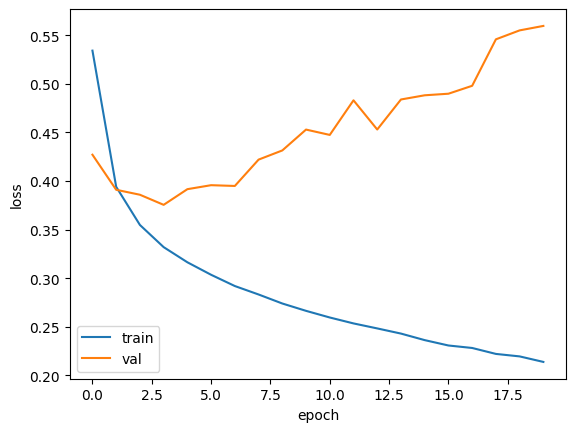

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

**결과분석**<br>
1.   초기에 검증 손실이 감소하다가 5번째 에포크 만에 다시 상승 함
2.   훈련 손실은 꾸준히 감소하기 때문에 과대 적합 모델이 만들어 짐
3.   검증 손실이 상승하는 시점을 가능한 늦추면 세트에 대한 손실이 줄어들고 검증세트에 대한 정확도가 증가할 것 같다.
4.   과대 적합을 막기 위한 방법으로는 예전에 사용했던 규제방식대신에 신경망에 특화된 규제방법(드롭아웃)을 사용해보자.

지금은 옵티마이져 (최적화) 하이퍼파라미터를 자동 조절하여 과대 적합을 완화시켜본다.<br>
RMSprop 옵티마이져는 많은 문제에서 잘~ 작동합니다. <br>
→ 다른 방법으로는 Adagrad, Adam 등이 있습니다.

**RMSprop**

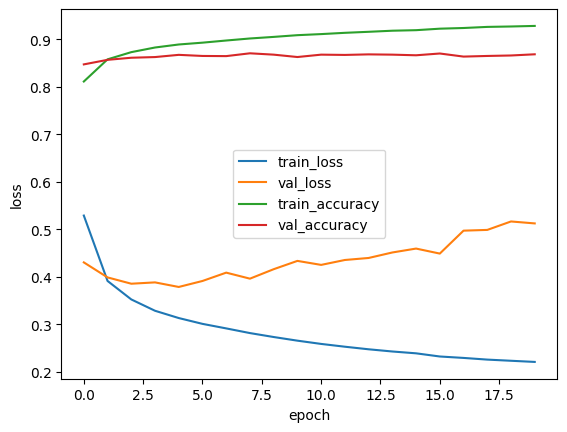

In [49]:
model = model_fn()
model.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

**adagrad**

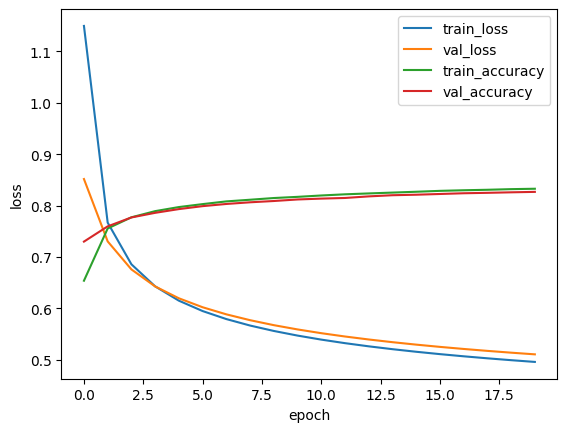

In [50]:
model = model_fn()
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

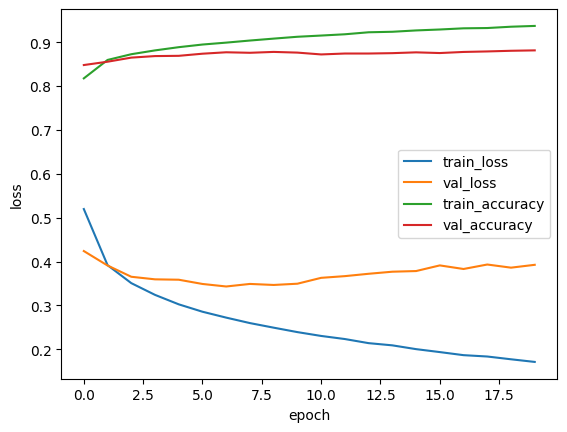

In [51]:
model = model_fn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

3가지 최적화 기법을 사용해보니 adam이 안정적으로 보인다.<br>
대신 과대적합을 막기위한 기법이 필요해 보인다.

*그래프의 수치가 다르기 때문에 값을 고정해서 비교해보자*<br><br>
**같은 축 범위로 강제 통일**<br>
loss / accuracy 그래프의 y축 범위를 동일하게 설정합니다.

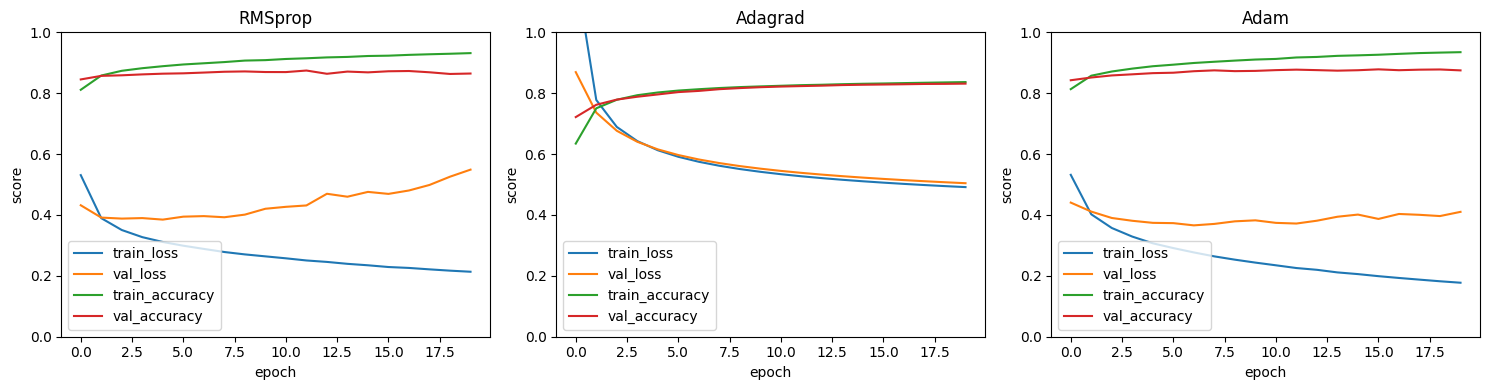

In [52]:
optimizers = {
    "RMSprop":"rmsprop",
    "Adagrad":keras.optimizers.Adagrad(),
    "Adam":"adam"
}

histories = {}

for name,opt in optimizers.items():
    model = model_fn()
    model.compile(optimizer=opt,
                  loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

    histories[name] = model.fit(
        train_scaled, train_target,
        epochs=20, verbose=0,
        validation_data=(val_scaled, val_target)
    )

plt.figure(figsize=(15,4))

for i, (name, history) in enumerate(histories.items(), 1):

    plt.subplot(1,3,i)

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(name)
    plt.xlabel('epoch')
    plt.ylabel('score')

    plt.ylim(0,1)
    plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.tight_layout()
plt.show()

**옵티마이저 그래프의 최적의 값을 찾기**

In [53]:
import numpy as np

for name, history in histories.items():

  val_loss = history.history['val_loss']

  best_epoch = np.argmin(val_loss) + 1
  best_loss = np.min(val_loss)

  print(f"{name}")
  print(f"Best Epoch:{best_epoch}")
  print(f"Best Val_Loss:{best_loss :.4f}")
  print()

RMSprop
Best Epoch:5
Best Val_Loss:0.3847

Adagrad
Best Epoch:20
Best Val_Loss:0.5043

Adam
Best Epoch:7
Best Val_Loss:0.3658



**드롭아웃(Dropout)**<br>
> 딥러닝의 기초가 되는 제프리 힌턴이 소개하였다. <br>

1.  훈련과정에서 층에 있는 일부 뉴런을 랜덤하게 꺼서 (뉴런 출력을 0으로 만듬) 과대 적합을 막는다.
2.  어떤 샘플을 처리할 때 은닉층의 두번째 뉴런이 드롭아웃되어 h2 출력이 없음
3.  다른 샘플을 처리 할 때는 은닉층의 첫번째 뉴런이 드롭아우되어 h1 출력이 없음
4.  뉴런은 랜덤하게 드롭아웃 되고 얼마나 많은 뉴런을 드롭할지 우리가 하이퍼파라미터에 정할 것이다.

> 드롭아웃이 왜 과대 적합을 막을 수 있을까?\

이전 층의 일부 뉴런이 랜덤하게 꺼지면 특저 뉴런에 과대하게 의존하는 것을 줄일 수 있고\
모든 입력에 대해 주의를 기울여야 한다. \
일부 뉴련의 출력이 없을 수 있다는 것을 감안하면 이 신경망은 더 안정적인 예측을 만들 수 있는 것이다.

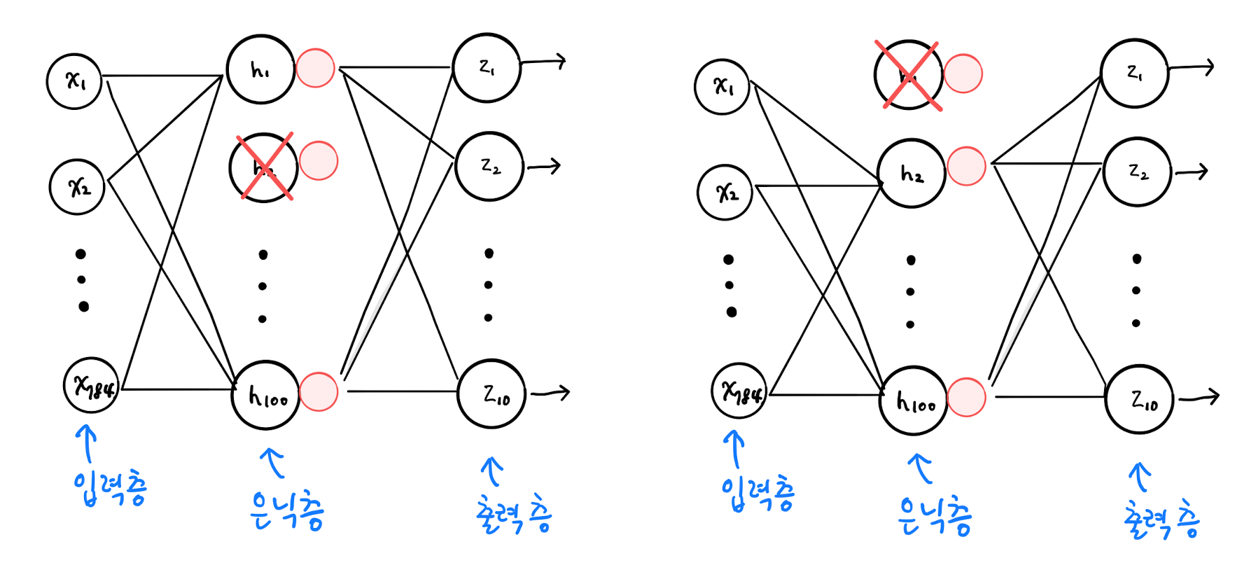

**또 다른 분석** \
앞으로 드롭아웃이 적용된 2개의 신경망을 앙상블하는 것 처럼 상상하게 됨\
**앙상블**: 다 좋은 예측을 만들기 위해 여러 개의 모델을 훈련하는 머신러닝 알고리즘 → 과대적합을 막아주는 좋은 기법이다.

---

케라스에서 드롭아웃을 **keras.layers.Dropout**로 제공한다.\
어떤 층의 뒤에 드롭아웃을 두어 이 층의 출력을 랜덤하게 0으로 만듬\
드롭아웃이 츠어럼 사용되지만 훈련되는 파라미터는 없다.\
\
model_fn() 함수에 드롭 아웃 객체를 전달하여 층을 추가해보자.

In [54]:
model = model_fn(keras.layers.Dropout(0.3))
# 30%정도 드롭아웃을 해보자

model.summary() # 요약확인

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

**주의사항**\
훈련이 끝난 뒤 평가나 예측을 수행할 때는 드롭아웃을 적용하지 않는다. \
텐서플로와 케라스는 모델을 평가와 예측에 사용할 때 자동으로 드롭아웃을 적용하지 않는다.\
\
훈련 손실과 검증손실의 그래프를 그려보자.

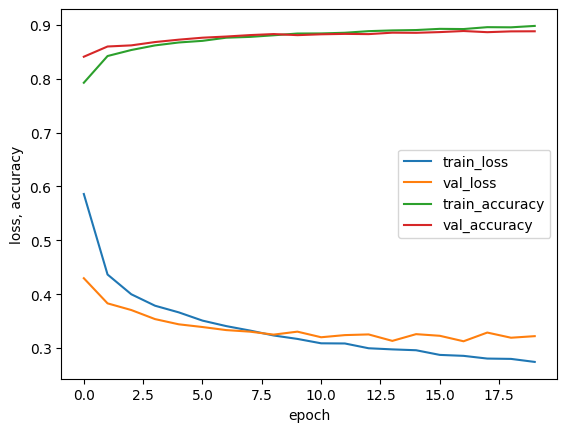

In [55]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

과대적합이 확실이 줄어들었다. \
10번째 에포크가 검증 소신의 감소가 멈추지만 크게 상승하지 않았다.\
20번의 에포크를 실행해서 결국 과대 적합이 되었다.→ 10번만 해볼까?\
(조기종료에서 해보자)\
\
차후에 재활용하기 위해서 모델 저장과 복원도 해본다.

In [56]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

model.save('model-whole-ep10.keras') # 모델 저장

케라스 모델은 훈련된 모델의 파라미터를 저장하는 save_weights() 메서드가 있다.\
텐서플로의 체크포인트 포멧으로 저장하지만 https://www.tensorflow.org/guide/checkpoint?hl=ko \
.h5일 경우 HDF5 포멧으로 저장함 https://geunuk.tistory.com/466\

In [57]:
model.save_weights('model-ep10.weights.h5') # HDF5 형식으로도 저장됨 (폴더에서 확인)

**model.save("model.keras")** : 모델 전체를 저장(자동차 설계도 + 엔진 + 연료 상태 모두 저장)\
**저장되는 것** : 모델 구조 (Layer 구조) / 학습된 가중치 / 옵티마이저 상태 / 컴파일 정보 (loss, metrics 등)\
즉 완전히 동일한 모델을 바로 복원 가능\
**model = load_model("model.keras")** : 모델 불러오기
코드 없이도 바로 복원 가능 -> 배포 / 추론용으로 많이 사용\

**model.save_weights("model_weights.h5")**
- 가중치만 저장(엔진만 저장)
저장되는 것 : 학습된 weights
- 저장되지 않는것 : 모델 구조 / optimizer 상태 / compile 정보

**model = create_model()**   동일한 구조 다시 생성 \
**model.load_weights("model_weights.h5")**
모델 구조 코드를 다시 만들어야 함 -> 실험 중간 체크포인트로 많이 사용


**오해금지!** -> 더미데이터는 저장하지 않는다.\
모델이 데이터 대신 기억하는 것은 패턴(가중치) 입니다.

```
훈련 데이터 (길이, 높이, 두께) → 생선 무게
훈련 후 모델이 저장하는 것 → weight1 = 0.23 / weight2 = 1.52 / bias = -0.77
```
## `데이터 → 학습 → 가중치`

```
model.keras (케라스모델 구조 : with zipfile.ZipFile("model.keras", 'r') as z:
                                print(z.namelist()) )
                                ['config.json', 'metadata.json', 'model.weights.h5']
  ├ config.json
  ├ metadata.json
  └ model.weights.h5

 config.json (모델 구조)
 {
  "class_name": "Sequential",
  "config": {
    "layers": [
      {
        "class_name": "Dense",
        "config": {
          "units": 64,
          "activation": "relu"
        }
      }
    ]
  }
 }


 model.weights.h5 (가중치)
 dense/kernel:0
 dense/bias:0
 dense_1/kernel:0
 dense_1/bias:0
 -> 실제 값 : 가중치만 저장(엔진만 저장)
  0.2312
 -0.7811
  0.5321

 metadata.json
 {
  "keras_version": "3.0",
  "backend": "tensorflow"
 }
```

이제는 저장한 모델을 불러와 테스트를 진행해보자

In [58]:
!ls -al model*

-rw-r--r-- 1 root root 976600 Mar  5 05:27 model-ep10.weights.h5
-rw-r--r-- 1 root root 979412 Mar  5 05:27 model-whole-ep10.keras


**실험 1**
훈련하지 않은 새로운 모델을 만들고 **model-ep10.weights.h5** 파일에서 \
훈련된 모델 파라미터를 읽어서 사용

model_fn() 위와 동일한 모델

In [59]:
model = model_fn(keras.layers.Dropout(0.3))
# 훈련하지 않은 새로운 모델

model.load_weights('model-ep10.weights.h5')
# 이전에 저장했던 모델 파라미터를 로딩

이때 사용하는 메서드는 save_weight()와 쌍을 이루는 load_weight() 메서드 이다.\
\
**주의사항** : load_weights() 메서드를 사용하려면 save_weight() 메서드로 저장했던 모델과 정확히 같은 구조를 가져야함

In [60]:
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

**모델의 검증 정확도를 확인 해보자.**

predict() 메서드는 사이킷 런과 다른 샘플마다 10개의 클래스에 대한 확률을 반환 (다중분류)\
\
패션 MNIST 데이터셋에서 덜어낸 검증 세트의 샘플수는 12,000개이기 때문에 predict()메서드는 (12000, 10)크기의 배열을 반환\
10개의 확률 중 가장 큰 값의 인덱스를 골라(.argmax) 타킷 레이블과 비교하여 정확도를 계산해보자

In [61]:
val_labels = np.argmax(model.predict(val_scaled), axis=-1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


axis=-1 배열의 마지막 차원을 따라 최대값을 고른다.\
검증세트는 2차원 배열이기 때문에 마지막 차원은 1이 된다.\
예를 들어 아래 그림처럼 5*3배열에 axis=1로 한값과 axis=0으로 한 값의 인덱스를 반환\
\
argmax()로 고른 인덱스(val_labels)와 타킷(val_target)을 비교하여 같으면 1이되고 다르면 0이된다.\
이를 평균으로 출력해 본다 (정확도)


In [62]:
print(np.mean(val_labels == val_target)) # 87.96% 평균

0.877


xis=1 이면 열을 따라 각 행의 최대값의 인덱스를 선택하고\
axis=0 이면 행을 따라 각 열의 최대값의 인덱스를 선택함.\
그 다음 라인은 argmax()로 고른 인덱스(val_labels)와 타킷(val_target)을 비교\
-> 두 배열에서 각 위치의 값이 같이면 1, 다르면 0 (평균하면 정확도가 됨)

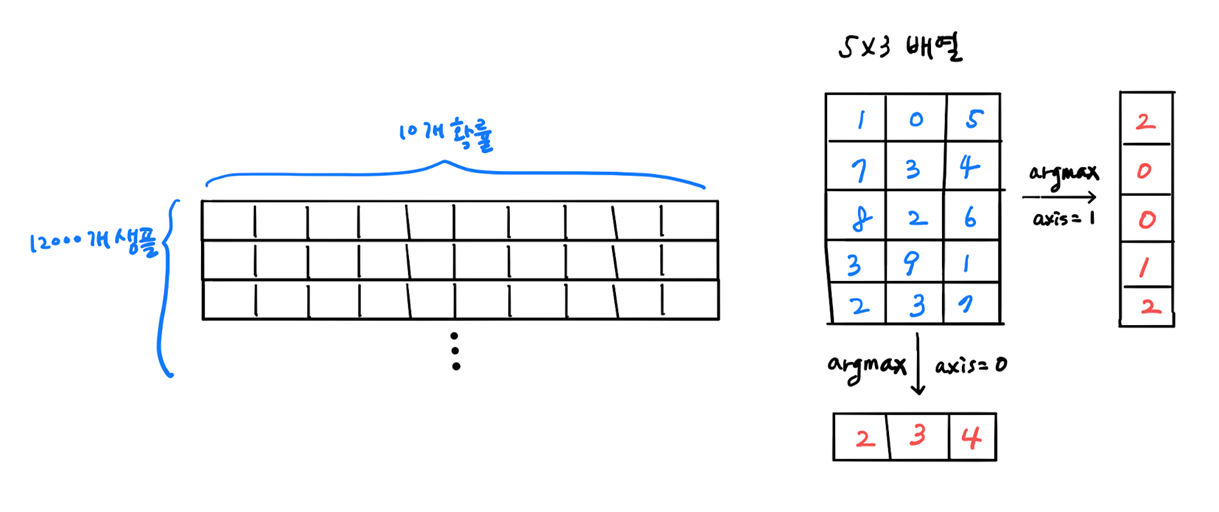

모델 전체를 파일에서 읽은 다음 검증 세트의 정확도를 출력 해봄

In [63]:
model = keras.models.load_model('model-whole-ep10.keras') # load_model()저장된 케라스 파일 읽기

model.evaluate(val_scaled, val_target) # 같은 모델을 불러 들였기 때문에 위와 정확도가 같음

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8810 - loss: 0.3350


[0.3384065330028534, 0.8769999742507935]

**현 상태 분석** : 20번의 에포크 동안 모델을 훈련하여 검증 점수가 상능하는 지점을 확인\
모델을 과대적합 되지 않은 에포크만큼 다시 훈련함\
모델을 두번씩 훈련하지 않고 한번에 끝내는 방법을 연구 해보자. -> 케라스 콜백\

https://ltlkodae.tistory.com/13 케라스 모델을 저장하는 방법 2가지 분석

**실험2**
아예 파일로 새로운 모델을 만들고 바로 사용해 보자.\
추가적으로 콜백이라는 것을 활용 해보자.\
**콜백** : 훈련과정 중간에 어떤 작업을 수행할 수 있게 하는 객체, 케라스.콜백 패키지에 있다.\
fit() 메서드의 callback 매개변수에 리스트로 전달하여 사용\
지금 우리가 사용할 콜백은 ModelCheckpoint 콜백으로 에포크마다 모델을 저장함\
save_best_only=True 매개변수를 지정하여 가장 낮은 검증 점수를 만드는 모델을 저장할 수 있다.

In [64]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)

model.fit(train_scaled, train_target, epochs=20, verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7306 - loss: 0.7712 - val_accuracy: 0.8453 - val_loss: 0.4242
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8374 - loss: 0.4548 - val_accuracy: 0.8577 - val_loss: 0.3833
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8518 - loss: 0.4145 - val_accuracy: 0.8689 - val_loss: 0.3652
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8596 - loss: 0.3871 - val_accuracy: 0.8680 - val_loss: 0.3558
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8656 - loss: 0.3708 - val_accuracy: 0.8747 - val_loss: 0.3417
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8688 - loss: 0.3562 - val_accuracy: 0.8751 - val_loss: 0.3346
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8715 - loss: 0.3478 - val_accuracy: 0.8775 - val_loss: 0.3331
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8761 - loss: 0.3381 - 

모델 훈련후 best-model.keras에 최상의 검증 점수를 낸 모델이 저장됨

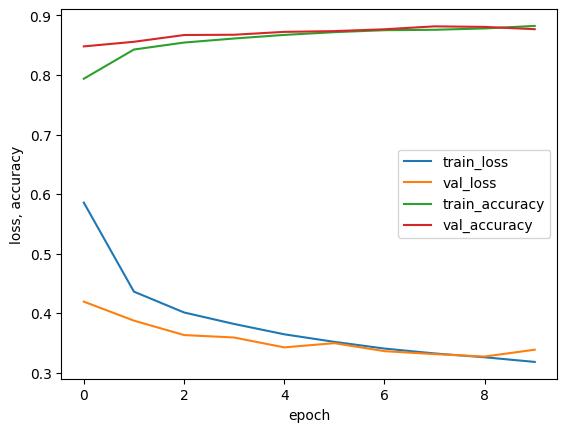

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8883 - loss: 0.3260


[0.33143556118011475, 0.8871666789054871]

In [65]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)

검증세트의 성능 확인 (33.10%, 87.99%) 에포크 9번\
결론 20번을 다 돌리고 좋은 점수가 나온 9번째 에포크를 저장함.\

keras.callbacks.ModelCheckpoint 콜백이 가장 낮은 검증 점수의 모델을 자동으로 저장해 주었음\
여전히 20번의 에포크 동안 훈련을 함\
사실 검증 점수가 상승하기 시작하면 그 이후에는 과대 적합이\
더 커지기 때문에 훈련을 계속할 필요가 없음.\
이때 훈련을 종료하면 자원과 시간일 아낄 수 있음 -> 조기종료(early stopping)\

조기 종료는 딥러닝 분야에 많이 사용하는 기법\
에포크의 횟수를 제한하는 역할이지만 모델이 과대적합되는 것을 막아주기도 함 - 규제방법중 하나\

케라스에는 조기종료를 위한 EarlyStopping 콜백을 제공함\
이 콜백의 patience 매개변수는 검증 점수가 향상되지 않더라도 참을 에포크 회수로 지정\
**patience=2** 2번 연속 검증 점수가 향상되지 않으면 훈련을 중지 (patience:인내심)\
**restore_best_weights=True **-> 가장 낮은 검증 솔실을 낸 모델 파리미터로 돌림

In [66]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)
# 가장 낮은 검증 손실의 모델을 파일에 저장하고 검증 손실이 다시 상승할 때 훈련을 중지할 수 있음.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True) # 얼리

# 훈련을 중지하고 현재 모델의 파라미터를 최상의 파라미터로 되돌림
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7266 - loss: 0.7919 - val_accuracy: 0.8414 - val_loss: 0.4355
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8372 - loss: 0.4564 - val_accuracy: 0.8520 - val_loss: 0.4022
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8496 - loss: 0.4185 - val_accuracy: 0.8648 - val_loss: 0.3676
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8554 - loss: 0.3942 - val_accuracy: 0.8684 - val_loss: 0.3628
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8642 - loss: 0.3715 - val_accuracy: 0.8702 - val_loss: 0.3529
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8678 - loss: 0.3628 - val_accuracy: 0.8737 - val_loss: 0.3456
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8721 - loss: 0.3496 - val_accuracy: 0.8721 - val_loss: 0.3487
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8783 - loss: 0.3376 - 

In [67]:
print(early_stopping_cb.stopped_epoch)  # 조기종료 시점 에포크

12


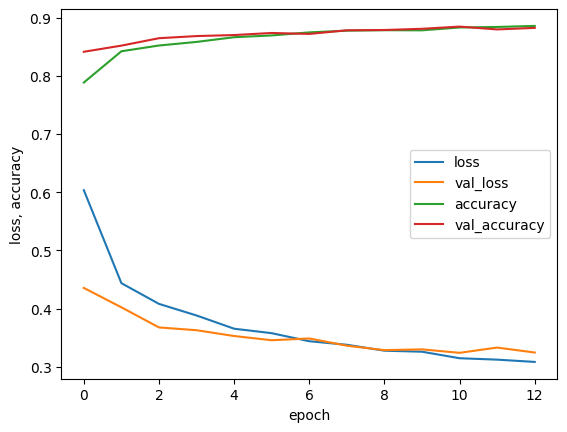

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8864 - loss: 0.3235


[0.32399022579193115, 0.8846666812896729]

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['loss', 'val_loss','accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)

검증세트의 성능 확인 (32.49%, 88.09%) 에포크 10번\
컴퓨터의 자원과 시간을 아끼고 콜백과 함꼐 사용하면 최상의 모델을 자동으로 저장해 준다는 것을 명심